# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




Unilateral de direita.

A hipótese alternativa é "A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.". Se a H1 for aceita, a função de B deve estar mais à direita, ou seja, para ser significativamente maior, o valor p deve estar para além do coeficiente de significância à direita. 

# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [18]:
media_A = amostra_estrategia_A.mean()
var_A = amostra_estrategia_A.var()
print(f"Estratégia A:\n Média: {round(media_A,2)}\n Variância: {round(var_A,2)}\n Desvio Padrão: {round(amostra_estrategia_A.std(),2)}")

media_B = amostra_estrategia_B.mean()
var_B = amostra_estrategia_B.var()
print(f"Estratégia B:\n Média: {round(media_B,2)}\n Variância: {round(var_B,2)}\n Desvio Padrão: {round(amostra_estrategia_B.std(),2)}")


Estratégia A:
 Média: 71.41
 Variância: 126.68
 Desvio Padrão: 11.26
Estratégia B:
 Média: 74.75
 Variância: 108.26
 Desvio Padrão: 10.4


A média da estratégia B é maior do que a média da estratégia A. A diferença entre elas não é grande e é "coberta" pela variância de ambas as estratégias. Isso pode indicar que a diferença não é significativa, mas s 

# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [20]:
# Tamanho das amostras
n = len(amostra_estrategia_A)

# Calcular a estatística de teste Z com a formula:
z_statistic = (media_B - media_A) / ((var_A/n + var_B/n)**0.5)


# Calcular o p-valor (teste unilateral direito)
p_valor = 1 - stats.norm.cdf(z_statistic)
# (teste unilateral esquerda)
# p_valor = stats.norm.cdf(z_statistic)
# teste bilateral
# p_valor = 2*(1 - stats.norm.cdf(abs(z_statistic)))
# stats.norm.cdf(abs(z_statistic)): Esta parte calcula a área sob a curva normal padrão até o valor absoluto da estatística de teste Z
# 2 * ...: Multiplicar o resultado em (2) por 2 quando for um teste bilateral.


# Imprimir os resultados
print("Estatística de teste Z:", z_statistic)
print("p-valor:", p_valor)

# Comparar o p-valor com o nível de significância
nivel_significancia = 0.05
if p_valor < nivel_significancia:
    print("Hipótese nula rejeitada: há diferença significativa entre as médias.")
else:
    print("Hipótese nula aceita: não há diferença significativa entre as médias.")

Estatística de teste Z: 1.542245935902539
p-valor: 0.06150692063904584
Hipótese nula aceita: não há diferença significativa entre as médias.


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

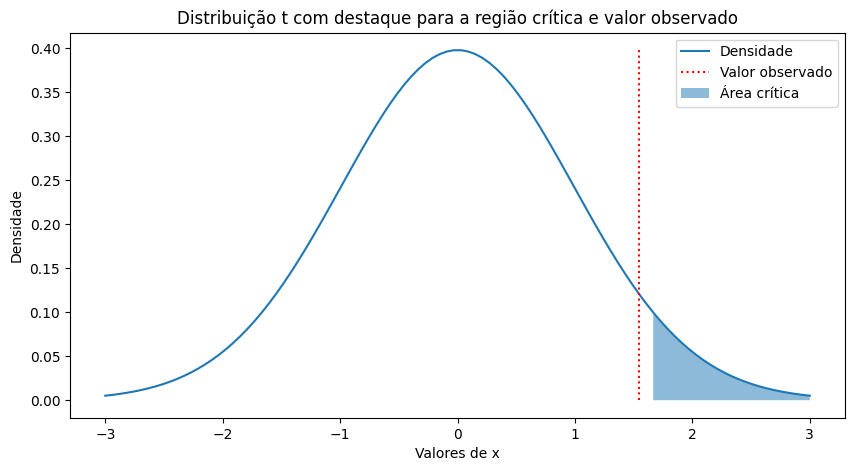

In [22]:
# Configurações padrão do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Parâmetros da densidade sob H0
mu = 0 # É a média da distribuição t sob a hipótese nula, no caso da distribuição t, a média é sempre 0.
variance = 1  # É a variância da distribuição t sob a hipótese nula, para a distribuição t, a variância é sempre 1.
sigma = variance**.5  #É o desvio padrão da distribuição t sob a hipótese nula. Como a variância é 1, o desvio padrão é a raiz quadrada da variância, ou seja, 1.

# Valores de X e Y para plotar a densidade do nosso gráfico
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = stats.t.pdf(x, len(amostra_estrategia_B) + len(amostra_estrategia_A) - 2)

# Essas linhas de código estão calculando os limites da região crítica do teste t
low = stats.t.ppf(.95, len(amostra_estrategia_B) + len(amostra_estrategia_A) - 2)
#len(taxa_conversao_antiga) - 2): Isso calcula o percentil 95 da distribuição t.
#
high = np.inf

# Gráfico da densidade
ax.plot(x, y, label='Densidade')

# Marcação do valor observado da estatística do teste
ax.vlines(x=[z_statistic], ymin=0, ymax=y.max(), colors='r', linestyles='dotted', label='Valor observado')

# Preenchendo a área crítica
plt.fill_between(x, y, where=(low < x) & (x < high), alpha=.5, label='Área crítica')

#Plotagem padrão do gráfico
plt.legend()
plt.xlabel('Valores de x')
plt.ylabel('Densidade')
plt.title('Distribuição t com destaque para a região crítica e valor observado')
plt.show()

É possível visualizar que a hipótese nula não foi rejeitada por que o valor de z observado está fora da área crítica. Uma forma de interpretar é que o fato do valor z estar dentro da normal e abaixo do coeficiente de significância